In [2]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print('imported packages successfully...')

imported packages successfully...


In [6]:
# load the data
df = pd.read_csv('employee_data.csv')
df.head()

,employee_id,name,role,years_experience,performance_score,current_salary
0,EMP0001,Sneha Tiwari,Senior Analyst,5.6,4.2,60000
1,EMP0002,Divya Kumar,Junior Engineer,3.2,2.1,39000
2,EMP0003,Nikhil Mehta,Analyst,1.8,3.9,38000
3,EMP0004,Arjun Pillai,Junior Engineer,3.5,2.5,55000
4,EMP0005,Sunita Sharma,Junior Engineer,2.2,2.3,44000


In [10]:
# display the shape
print(f'Data shape: {df.shape}')

# first 10 rows of data
df.head(10)




Data shape: (500, 6)


,employee_id,name,role,years_experience,performance_score,current_salary
0,EMP0001,Sneha Tiwari,Senior Analyst,5.6,4.2,60000
1,EMP0002,Divya Kumar,Junior Engineer,3.2,2.1,39000
2,EMP0003,Nikhil Mehta,Analyst,1.8,3.9,38000
3,EMP0004,Arjun Pillai,Junior Engineer,3.5,2.5,55000
4,EMP0005,Sunita Sharma,Junior Engineer,2.2,2.3,44000
5,EMP0006,Ananya Malhotra,Senior Analyst,7.3,2.4,73000
6,EMP0007,Ananya Patel,Team Lead,11.5,4.1,95000
7,EMP0008,Deepa Rao,Senior Engineer,8.5,3.1,102000
8,EMP0009,Divya Iyer,Team Lead,9.3,2.8,114000
9,EMP0010,Suresh Tiwari,Analyst,3.9,2.5,56000


In [13]:
# check for null and na values
print('───────────────────────── null check ─────────────────────────')
print(df.isnull().sum())

print('\n───────────────────────── na check ─────────────────────────')
print(df.isna().sum())

───────────────────────── null check ─────────────────────────
employee_id          0
name                 0
role                 0
years_experience     0
performance_score    0
current_salary       0
dtype: int64

───────────────────────── na check ─────────────────────────
employee_id          0
name                 0
role                 0
years_experience     0
performance_score    0
current_salary       0
dtype: int64


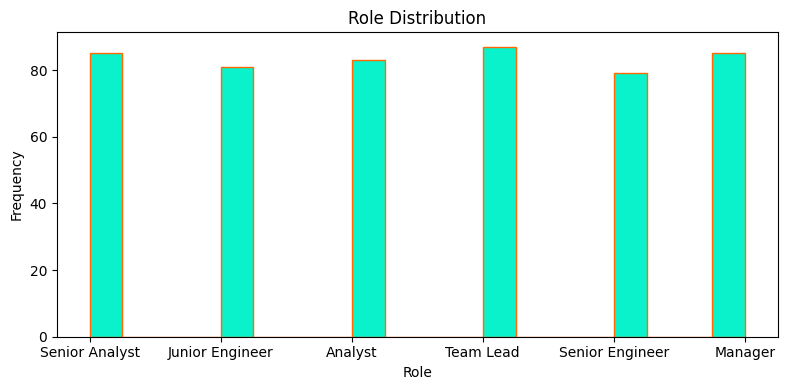

In [17]:
# frequency of role distribution
plt.figure(figsize= [8, 4])
plt.hist(df['role'], bins=20, color='#0af2cb', edgecolor='#ff6a00')
plt.title('Role Distribution')
plt.xlabel('Role')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [19]:
# encode Role column
role_map = {
    'Analyst' : 1,
    'Junior Engineer' : 2,
    'Senior Analyst' : 3,
    'Senior Engineer' : 4,
    'Team Lead' : 5,
    'Manager' : 6
}

df['role_encoded'] = df['role'].map(role_map)

print('───────────────────────── verify role_encoded column ─────────────────────────')
df.head(10)

───────────────────────── verify role_encoded column ─────────────────────────


,employee_id,name,role,years_experience,performance_score,current_salary,role_encoded
0,EMP0001,Sneha Tiwari,Senior Analyst,5.6,4.2,60000,3
1,EMP0002,Divya Kumar,Junior Engineer,3.2,2.1,39000,2
2,EMP0003,Nikhil Mehta,Analyst,1.8,3.9,38000,1
3,EMP0004,Arjun Pillai,Junior Engineer,3.5,2.5,55000,2
4,EMP0005,Sunita Sharma,Junior Engineer,2.2,2.3,44000,2
5,EMP0006,Ananya Malhotra,Senior Analyst,7.3,2.4,73000,3
6,EMP0007,Ananya Patel,Team Lead,11.5,4.1,95000,5
7,EMP0008,Deepa Rao,Senior Engineer,8.5,3.1,102000,4
8,EMP0009,Divya Iyer,Team Lead,9.3,2.8,114000,5
9,EMP0010,Suresh Tiwari,Analyst,3.9,2.5,56000,1


In [20]:
# features for clustering
features = ['years_experience', 'performance_score', 'current_salary', 'role_encoded']

x = df[features]

x.head(10)

,years_experience,performance_score,current_salary,role_encoded
0,5.6,4.2,60000,3
1,3.2,2.1,39000,2
2,1.8,3.9,38000,1
3,3.5,2.5,55000,2
4,2.2,2.3,44000,2
5,7.3,2.4,73000,3
6,11.5,4.1,95000,5
7,8.5,3.1,102000,4
8,9.3,2.8,114000,5
9,3.9,2.5,56000,1


In [23]:
print(f'x shape: {x.shape}')
print(x.info())
print(x.describe())

x shape: (500, 4)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   years_experience   500 non-null    float64
 1   performance_score  500 non-null    float64
 2   current_salary     500 non-null    int64  
 3   role_encoded       500 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 15.8 KB
None
       years_experience  performance_score  current_salary  role_encoded
count        500.000000          500.00000      500.000000    500.000000
mean           7.640600            3.55280    85586.000000      3.522000
std            4.338846            0.85395    37446.375874      1.715635
min            1.000000            2.00000    30000.000000      1.000000
25%            3.500000            2.80000    51000.000000      2.000000
50%            7.400000            3.55000    78500.000000      4.000000
75%           10.925000           

In [28]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)
x_scaled[:5,:]

array([[-0.47078043,  0.75864882, -0.68395469, -0.30456527],
       [-1.0244769 , -1.70297437, -1.24531827, -0.88802365],
       [-1.34746651,  0.40698837, -1.27204987, -1.47148203],
       [-0.95526484, -1.23409376, -0.81761269, -0.88802365],
       [-1.25518376, -1.46853407, -1.11166027, -0.88802365]])

In [57]:
inertia = []

k_range = range(1, 21)

for i in k_range:
    model = KMeans(n_clusters=i, random_state=42)
    model.fit(x_scaled)
    inertia.append(model.inertia_)


print('───────────────────────── inertia ─────────────────────────')
print(inertia)

───────────────────────── inertia ─────────────────────────
[2000.0000000000005, 934.0559425187116, 682.5315678813672, 537.4820549432827, 409.8454393771993, 314.0054307037712, 274.475783196724, 251.37237043122494, 226.77844815624226, 211.6904765568779, 182.11114965944847, 171.8754448633384, 163.95878978150452, 155.7771912997296, 152.05992086295277, 144.00361555838577, 140.28840163879107, 136.76779120606238, 131.16278446252585, 128.13692124954738]


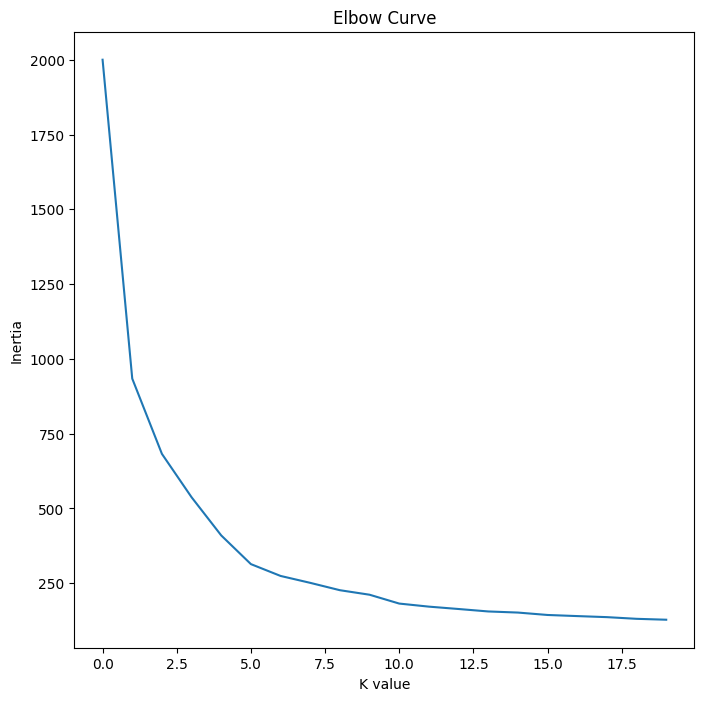

In [58]:
# plot the graph
plt.figure(figsize=[8, 8])
# plt.Line2D(k_range, inertia)
plt.plot(inertia)
plt.xlabel('K value')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [59]:
OPTIMAL_K = 5

# create K means model
model = KMeans(n_clusters=OPTIMAL_K, random_state=42)
df['cluster'] = model.fit_predict(x_scaled)
df.head(10)

,employee_id,name,role,years_experience,performance_score,current_salary,role_encoded,cluster
0,EMP0001,Sneha Tiwari,Senior Analyst,5.6,4.2,60000,3,4
1,EMP0002,Divya Kumar,Junior Engineer,3.2,2.1,39000,2,3
2,EMP0003,Nikhil Mehta,Analyst,1.8,3.9,38000,1,0
3,EMP0004,Arjun Pillai,Junior Engineer,3.5,2.5,55000,2,3
4,EMP0005,Sunita Sharma,Junior Engineer,2.2,2.3,44000,2,3
5,EMP0006,Ananya Malhotra,Senior Analyst,7.3,2.4,73000,3,3
6,EMP0007,Ananya Patel,Team Lead,11.5,4.1,95000,5,1
7,EMP0008,Deepa Rao,Senior Engineer,8.5,3.1,102000,4,4
8,EMP0009,Divya Iyer,Team Lead,9.3,2.8,114000,5,2
9,EMP0010,Suresh Tiwari,Analyst,3.9,2.5,56000,1,3


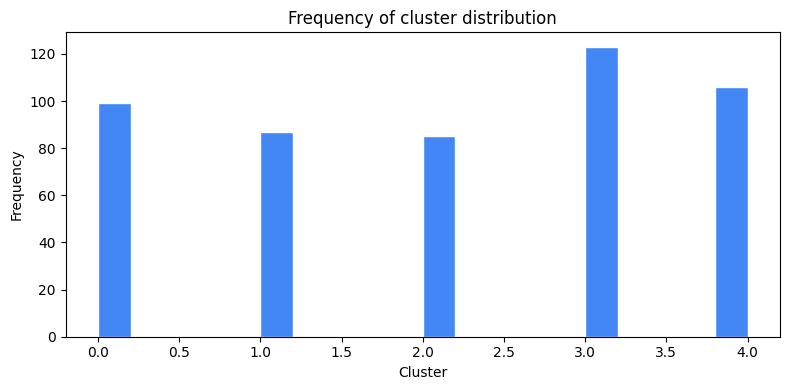

In [66]:
# frequency of cluster distribution
plt.figure(figsize=[8,4])
plt.hist(df['cluster'], bins=20, color='#4287f5', edgecolor='#ffffff')
plt.xlabel('Cluster')
plt.ylabel('Frequency')
plt.title('Frequency of cluster distribution')
plt.tight_layout()
plt.show()

In [ ]:
# step-8